# 23. The `LASS` K-pi S-wave lineshape

**Objectives:**
- Build `LASS`, the Laura++ K-pi S-wave: an effective-range nonresonant term plus a
  K0*(1430) resonant term.
- Compare `mode="full"` against `mode="nonresonant"` and `mode="resonant"` on one plot.
- Confirm `LASS` only accepts a spin-0 daughter pair, catching the `ValueError` it raises
  otherwise.
- Embed it in a minimal one-resonance `DecayModel`, generate a toy, and recover a floated
  Cartesian coefficient with `FitSession.fit()`.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and
daughter indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, LASS, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)
from dalitzplotfitter.dynamics.context import ResonanceContext

## 1. `mode="full"` vs `"resonant"` vs `"nonresonant"`

`LASS.terms(mass, context)` returns `(nonresonant, resonant)` separately; `__call__` sums
them for `mode="full"` (the default), or returns just one term for `mode="resonant"`/
`"nonresonant"`. The nonresonant term uses an effective-range expansion
(`scattering_length`, `effective_range`) optionally cut off above `cutoff` (default 1.8 GeV);
the resonant term is a relativistic Breit-Wigner for the K0*(1430) dressed by the LASS phase
`phase2 = (cot(delta_B) + i) / (cot(delta_B) - i)`. We use a K-pi daughter pair, matching the
class's own docstring ("Laura++ K-pi S-wave").

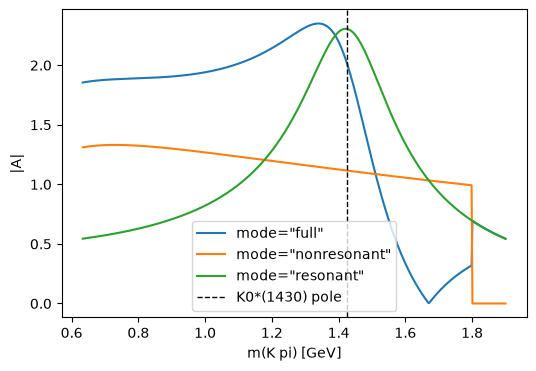

In [2]:
mk, mpi = 0.493677, 0.13957039
context = ResonanceContext(
    parent_mass=1.86965, daughter_masses=(mk, mpi), bachelor_mass=mpi,
    spin=0, pole_mass=1.425, pole_width=0.270,
)
mass_scan = jnp.linspace(mk + mpi + 1e-4, 1.90, 500)

full = LASS(mode="full")(mass_scan, context)
nonresonant = LASS(mode="nonresonant")(mass_scan, context)
resonant = LASS(mode="resonant")(mass_scan, context)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mass_scan, jnp.abs(full), label='mode="full"')
ax.plot(mass_scan, jnp.abs(nonresonant), label='mode="nonresonant"')
ax.plot(mass_scan, jnp.abs(resonant), label='mode="resonant"')
ax.axvline(1.425, color="black", linestyle="--", linewidth=1, label="K0*(1430) pole")
ax.set(xlabel="m(K pi) [GeV]", ylabel="|A|")
ax.legend()
plt.show()

`"full"` is exactly the sum of the other two, as `LASS.__call__` computes it from
`terms()`.

In [3]:
import numpy as np
np.testing.assert_allclose(full, nonresonant + resonant, atol=1e-12)
print("mode='full' equals nonresonant + resonant, as terms() documents.")

mode='full' equals nonresonant + resonant, as terms() documents.


## 2. `LASS` requires a spin-0 pair

The docstring of `LASS.terms` states: "LASS is defined for a spin-0 K-pi S-wave." Passing a
`ResonanceContext` with `spin != 0` raises a `ValueError` at evaluation time. Neither building
a `Resonance` with `spin=1` nor building `DecayModel` itself evaluates the lineshape eagerly
(both are lazy, declarative containers), so the error only surfaces once something actually
evaluates the amplitude on the Dalitz plot -- generating a toy is the simplest way to force
that.

In [4]:
channel = DecayChannel("D+", ("K-", "pi+", "pi+"))

bad_model = DecayModel(
    channel,
    components=[
        Resonance(
            "kpi_lass_spin1", pair=(0, 1), coefficient=RealImag(1.0, 0.0),
            lineshape=LASS(), mass=1.425, width=0.270, spin=1,
            normalize_component=False,
        ),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=40,
)

try:
    generate_toy(
        bad_model, 10, parameters={p.name: p.value for p in bad_model.parameters},
        seed=0, method="inverse-transform", inverse_resolution=32,
        include_momenta=False,
    )
except ValueError as exc:
    print(f"Caught expected ValueError: {exc}")
else:
    raise AssertionError("Expected LASS with spin != 0 to raise ValueError")

Caught expected ValueError: LASS is defined for a spin-0 K-pi S-wave


## 3. A minimal one-resonance Dalitz model

With `spin=0` the same component builds cleanly. We use `D+ -> K- pi+ pi+`, with the LASS
K0*(1430) on the `(0, 1)` = K-pi pair, plus a small non-resonant term for interference.

In [5]:
def coeff(name, x0, y0):
    return RealImag(
        Parameter.coefficient(f"{name}.x", x0, owner=name, bounds=(-3.0, 3.0)),
        Parameter.coefficient(f"{name}.y", y0, owner=name, bounds=(-3.0, 3.0)),
    )

model = DecayModel(
    channel,
    components=[
        Resonance(
            "kpi_lass", pair=(0, 1), coefficient=coeff("kpi_lass", 1.0, 0.0),
            lineshape=LASS(), mass=1.425, width=0.270, spin=0,
            normalize_component=False,
        ),
        NonResonant(coeff("NR", 0.25, -0.10), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=40,
)
truth = {p.name: p.value for p in model.parameters}
print("Floating parameters:", list(truth))

Floating parameters: ['kpi_lass.x', 'kpi_lass.y', 'NR.x', 'NR.y']


## 4. Generate a toy and fit the Cartesian coefficient

We generate a small toy at the truth values and float `kpi_lass.x`/`kpi_lass.y` from a
displaced starting point, keeping everything else fixed.

In [6]:
toy = generate_toy(
    model, 1500, parameters=truth, seed=23,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Generated {toy.size} toy events")

session = FitSession(model, toy)
start = {"kpi_lass.x": 0.7, "kpi_lass.y": 0.3}
result = session.fit(start, simplex=True, ncall=4000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before using this result."

fit_values = {n: float(result.values[n]) for n in result.parameters}
fit_nll = float(session.objective(fit_values))
truth_nll = float(session.objective(truth))
print(f"NLL(fit)={fit_nll:.4f}, NLL(truth)={truth_nll:.4f}")
assert fit_nll <= truth_nll + 1e-3
print("The fit converged to a valid minimum with NLL at or below the truth NLL.")

Generated 1500 toy events


E0916 10:58:45.760728 1277170 cuda_executor.cc:1348] [0] Failed to allocate device memory of 64.00MiB (67108864 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla+/xla/stream_executor/cuda/cuda_status.cc:45
external/xla+/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla+/xla/stream_executor/cuda/cuda_device_allocator.cc:389



valid=True  NLL=1444.948700
parameter                           value            error
kpi_lass.x                       0.424327          4.63653
kpi_lass.y                       0.567775          4.24907
NR.x                             0.193099          2.20838
NR.y                            -0.120847          1.81561


Fit fractions (physical)
component                    fraction [%]
kpi_lass                          108.925
NR                                  0.321
sum                               109.247


NLL(fit)=1444.9487, NLL(truth)=1445.7583
The fit converged to a valid minimum with NLL at or below the truth NLL.


## Summary

- `LASS` is a two-term K-pi S-wave (effective-range nonresonant + K0*(1430) resonant), with
  `mode=` selecting which term(s) `__call__` returns.
- It only accepts a spin-0 daughter pair; a spin mismatch raises `ValueError` as soon as the
  lineshape is actually evaluated (e.g. while generating a toy or fitting), since neither
  `Resonance` nor `DecayModel` evaluates it eagerly at construction time.
- Its complex coefficient floats through `FitSession.fit()` exactly like any other resonance,
  as long as it is built with `Parameter.coefficient(..., owner=...)` rather than fixed floats.

See `docs/lineshapes.md` for the full lineshape catalog.

Return to [the course guide](TUTORIALS.md).